In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report, 
                             roc_auc_score, roc_curve,precision_score,recall_score,f1_score)

In [2]:
df = pd.read_csv("patient_data.csv")

In [3]:
df.shape

(200020, 17)

In [4]:
df.columns

Index(['Patient ID', 'Heart Rate', 'Respiratory Rate', 'Timestamp',
       'Body Temperature', 'Oxygen Saturation', 'Systolic Blood Pressure',
       'Diastolic Blood Pressure', 'Age', 'Gender', 'Weight (kg)',
       'Height (m)', 'Derived_HRV', 'Derived_Pulse_Pressure', 'Derived_BMI',
       'Derived_MAP', 'Risk Category'],
      dtype='object')

In [6]:
df = df.drop(['Patient ID', 'Timestamp','Derived_MAP','Derived_BMI','Derived_Pulse_Pressure','Derived_HRV'], axis=1)


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200020 entries, 0 to 200019
Data columns (total 11 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Heart Rate                200020 non-null  int64  
 1   Respiratory Rate          200020 non-null  int64  
 2   Body Temperature          200020 non-null  float64
 3   Oxygen Saturation         200020 non-null  float64
 4   Systolic Blood Pressure   200020 non-null  int64  
 5   Diastolic Blood Pressure  200020 non-null  int64  
 6   Age                       200020 non-null  int64  
 7   Gender                    200020 non-null  object 
 8   Weight (kg)               200020 non-null  float64
 9   Height (m)                200020 non-null  float64
 10  Risk Category             200020 non-null  object 
dtypes: float64(4), int64(5), object(2)
memory usage: 16.8+ MB


In [8]:
print(df['Risk Category'].value_counts(normalize=True) * 100)

Risk Category
High Risk    52.552245
Low Risk     47.447755
Name: proportion, dtype: float64


In [9]:
df['Risk Category'] = df['Risk Category'].map({'Low Risk': 0, 'High Risk': 1})

In [10]:
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1}).astype('category')


In [11]:
df = df.fillna(df.median(numeric_only=True))


In [12]:
df.isna().sum()

Heart Rate                  0
Respiratory Rate            0
Body Temperature            0
Oxygen Saturation           0
Systolic Blood Pressure     0
Diastolic Blood Pressure    0
Age                         0
Gender                      0
Weight (kg)                 0
Height (m)                  0
Risk Category               0
dtype: int64

In [16]:
X = df.drop(columns=['Risk Category'])
y = df['Risk Category']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

In [18]:
params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'lambda_l2': 0.1,
    'verbose': -1
}

In [19]:
train_data = lgb.Dataset(X_train, label=y_train)
valid_data = lgb.Dataset(X_test, label=y_test)

In [20]:
from lightgbm import early_stopping, log_evaluation
import time
start_time =time.time()
model = lgb.train(
    params,
    train_data,
    num_boost_round=1000,
    valid_sets=[train_data, valid_data],
    callbacks=[
        early_stopping(stopping_rounds=100),
        log_evaluation(100)
    ]
)
end_time=time.time()
training_time=end_time-start_time
print("Training time",training_time)


Training until validation scores don't improve for 100 rounds
[100]	training's binary_logloss: 0.0490937	valid_1's binary_logloss: 0.050106
[200]	training's binary_logloss: 0.0154383	valid_1's binary_logloss: 0.0169528
[300]	training's binary_logloss: 0.00965297	valid_1's binary_logloss: 0.0117743
[400]	training's binary_logloss: 0.0065845	valid_1's binary_logloss: 0.00932624
[500]	training's binary_logloss: 0.00490715	valid_1's binary_logloss: 0.0081249
[600]	training's binary_logloss: 0.00361361	valid_1's binary_logloss: 0.00718107
[700]	training's binary_logloss: 0.00273372	valid_1's binary_logloss: 0.00664884
[800]	training's binary_logloss: 0.00209925	valid_1's binary_logloss: 0.00635963
[900]	training's binary_logloss: 0.00161989	valid_1's binary_logloss: 0.00602849
[1000]	training's binary_logloss: 0.00128557	valid_1's binary_logloss: 0.00590032
Did not meet early stopping. Best iteration is:
[1000]	training's binary_logloss: 0.00128557	valid_1's binary_logloss: 0.00590032
Train

In [21]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

In [22]:
print("Classification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     18981
           1       1.00      1.00      1.00     21023

    accuracy                           1.00     40004
   macro avg       1.00      1.00      1.00     40004
weighted avg       1.00      1.00      1.00     40004



In [23]:
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.9979002099790021


In [24]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)



In [25]:
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

Accuracy  : 0.9979
Precision : 0.9980
Recall    : 0.9980
F1-score  : 0.9980
ROC-AUC   : 1.0000


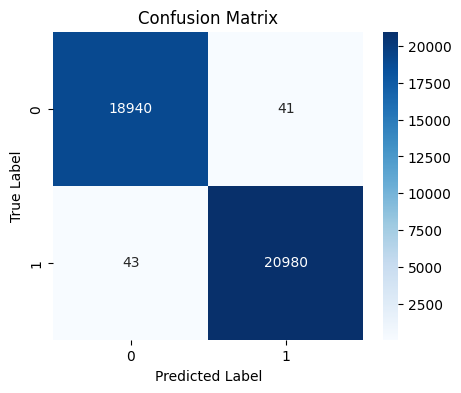

In [26]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

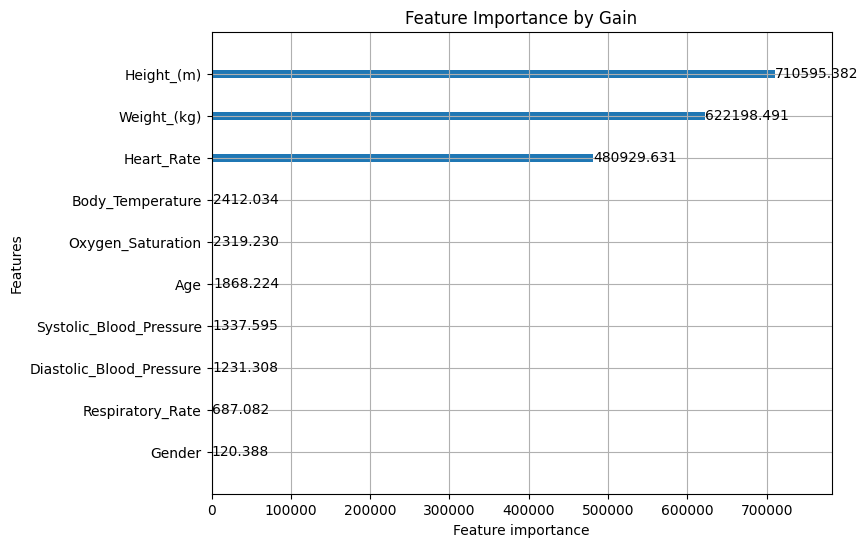

In [27]:
lgb.plot_importance(model, importance_type='gain', max_num_features=15, figsize=(8,6))
plt.title("Feature Importance by Gain")
plt.show()

In [28]:
df.corr()['Risk Category'].sort_values(ascending=False)

Risk Category               1.000000
Heart Rate                  0.368487
Weight (kg)                 0.024642
Diastolic Blood Pressure    0.003607
Gender                      0.002528
Age                         0.002466
Body Temperature            0.001181
Oxygen Saturation          -0.000652
Respiratory Rate           -0.001312
Systolic Blood Pressure    -0.003534
Height (m)                 -0.091435
Name: Risk Category, dtype: float64

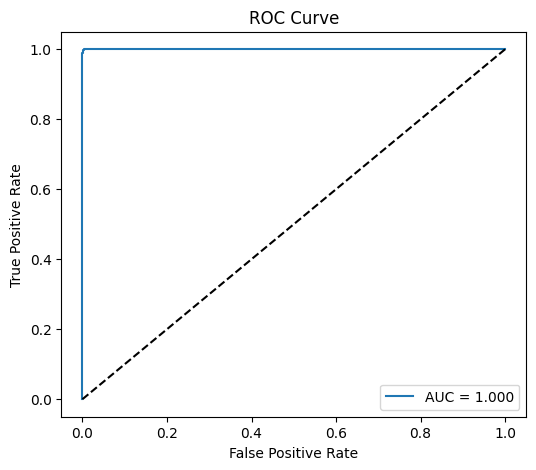

In [29]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_pred_prob):.3f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [30]:
model.save_model("patient_risk_model.txt")
print("✅ Model saved as patient_risk_model.txt")

✅ Model saved as patient_risk_model.txt


In [31]:
model_loaded = lgb.Booster(model_file='patient_risk_model.txt')

In [32]:
new_patients_raw = pd.DataFrame([
    [78, 16, 36.7, 97.5, 118, 78, 50, 1, 72.0, 1.72, 0.10],  # Normal vitals
    [105, 25, 38.2, 92.0, 155, 98, 68, 0, 90.0, 1.65, 0.12],  # Very high HR, RR, BP, Temp, low O2
    [65, 14, 36.2, 96.0, 112, 70, 30, 1, 65.0, 1.60, 0.09],  # Low age, normal vitals
    [92, 20, 37.5, 94.0, 140, 88, 55, 0, 85.0, 1.70, 0.11]   # Borderline vitals 
], columns=['Heart Rate','Respiratory Rate','Body Temperature','Oxygen Saturation',
            'Systolic Blood Pressure','Diastolic Blood Pressure','Age','Gender',
            'Weight (kg)','Height (m)','Derived_HRV'])  

new_patients_raw['Derived_Pulse_Pressure'] = new_patients_raw['Systolic Blood Pressure'] - new_patients_raw['Diastolic Blood Pressure']
new_patients_raw['Derived_BMI'] = new_patients_raw['Weight (kg)'] / (new_patients_raw['Height (m)']**2)
new_patients_raw['Derived_MAP'] = new_patients_raw['Diastolic Blood Pressure'] + new_patients_raw['Derived_Pulse_Pressure']/3

new_patients_raw['Gender'] = new_patients_raw['Gender'].astype('category')

pred_probs = model_loaded.predict(new_patients_raw)
pred_labels = ['High Risk' if p > 0.5 else 'Low Risk' for p in pred_probs]

for i, (p, label) in enumerate(zip(pred_probs, pred_labels)):
    print(f"Patient {i+1}: Predicted {label} (Probability={p:.3f})")


LightGBMError: The number of features in data (14) is not the same as it was in training data (10).
You can set ``predict_disable_shape_check=true`` to discard this error, but please be aware what you are doing.